# Hamiltonian Flow Matching — Harmonic Potential

Transports 8-Gaussians → Moons under the **harmonic potential** `V(x) = ½ xᵀUx`.
The path mean follows an eigendecomposition-based cosine/sine formula.

Two training variants:
1. **Basic CFM** — MSE on the conditional velocity field.
2. **Physics-informed** — adds `λ · ‖∂v/∂t + ∇V(x)‖²` regularisation (Hamiltonian PDE constraint).

After training, Hamiltonian conservation `H(t) = ½‖v‖² + V(x)` is measured along trajectories.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchdyn.core import NeuralODE

from torchcfm.hamiltonian import (
    HarmonicPotential, HarmonicGaussianPath, HamiltonianFlowMatcher,
    flow_matching_loss, combined_loss,
    finite_difference_time_derivative, hamiltonian_physics_loss,
    hamiltonian_energy, relative_hamiltonian_drift, plot_hamiltonian,
)
from torchcfm.models.models_v2 import MLP
from torchcfm.utils import sample_8gaussians, sample_moons, torch_wrapper

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

dim        = 2
batch_size = 256
n_iters    = 30_000
lr         = 1e-3
sigma      = 0.01
lambda_    = 1e-3   # physics loss weight

# Symmetric positive definite potential matrix
U = torch.tensor([[4.0, 0.0], [0.0, 1.0]])

print(f'device: {device}')
print(f'U =\n{U}')

device: cuda
U =
tensor([[4., 0.],
        [0., 1.]])


## Potential, path and flow matcher

In [3]:
potential = HarmonicPotential(U)
path      = HarmonicGaussianPath(U, sigma=sigma)
fm        = HamiltonianFlowMatcher(path, coupling='ot')

print('Eigenvalues of U:', path.D.numpy())
print('sqrt(trace(U))  :', path.sqrt_trace_U.item())

Eigenvalues of U: [1. 4.]
sqrt(trace(U))  : 2.2360680103302


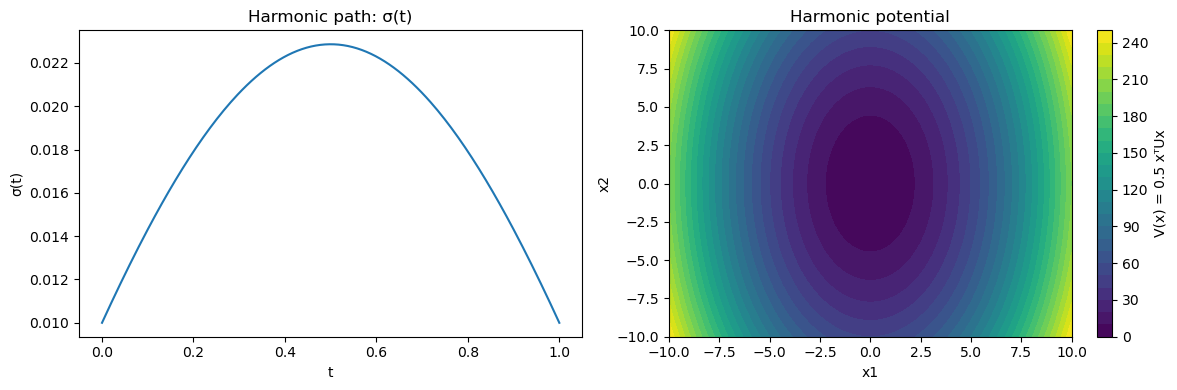

In [4]:
# Visualise σ(t) and potential
n_pts   = 200
t_demo  = torch.linspace(0, 1, n_pts)
x0_demo = torch.zeros(n_pts, dim)
x1_demo = torch.ones(n_pts, dim)

with torch.no_grad():
    _, sigma_t = path.compute(x0_demo, x1_demo, t_demo, return_derivatives=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_demo, sigma_t[:, 0])
axes[0].set_xlabel('t'); axes[0].set_ylabel('σ(t)')
axes[0].set_title('Harmonic path: σ(t)')

g    = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(g, g)
xy   = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)
Z    = potential.energy(xy).numpy().reshape(100, 100)
cf   = axes[1].contourf(X, Y, Z, levels=30, cmap='viridis')
plt.colorbar(cf, ax=axes[1], label='V(x) = 0.5 xᵀUx')
axes[1].set_title('Harmonic potential'); axes[1].set_xlabel('x1'); axes[1].set_ylabel('x2')
plt.tight_layout(); plt.show()

## Training — Variant A: Basic CFM

In [5]:
model_A     = MLP(dim + 1, out_dim=dim, w=64).to(device)
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=lr)

model_A.train()
losses_A = []

for k in range(n_iters):
    optimizer_A.zero_grad()
    x0 = sample_8gaussians(batch_size).to(device)
    x1 = sample_moons(batch_size).to(device)

    t, xt, ut = fm.sample_location_and_conditional_flow(x0, x1)
    vt   = model_A(torch.cat([xt, t], dim=-1))
    loss = flow_matching_loss(vt, ut)

    loss.backward()
    optimizer_A.step()
    losses_A.append(loss.item())

    if k % 5000 == 0 or k == n_iters - 1:
        print(f'[A] step {k:5d}: loss = {loss.item():.5f}')

[A] step     0: loss = 21.26090
[A] step  5000: loss = 0.40966
[A] step 10000: loss = 0.45736
[A] step 15000: loss = 0.26243
[A] step 20000: loss = 0.23881
[A] step 25000: loss = 0.20640
[A] step 29999: loss = 0.38082


## Training — Variant B: Physics-Informed (Hamiltonian PDE constraint)

Adds penalty `λ · ‖dv/dt + ∇V(x)‖²` to enforce the Hamiltonian equation of motion.
The time derivative `dv/dt` is estimated via central finite differences.

In [6]:
model_B     = MLP(dim + 1, out_dim=dim, w=64).to(device)
optimizer_B = torch.optim.Adam(model_B.parameters(), lr=lr)

model_B.train()
losses_B = []

for k in range(n_iters):
    optimizer_B.zero_grad()
    x0 = sample_8gaussians(batch_size).to(device)
    x1 = sample_moons(batch_size).to(device)

    t, xt, ut = fm.sample_location_and_conditional_flow(x0, x1)
    vt     = model_B(torch.cat([xt, t], dim=-1))
    fl     = flow_matching_loss(vt, ut)

    vt_t   = finite_difference_time_derivative(model_B, xt, t)
    grad_V = potential.gradient(xt)
    pl     = hamiltonian_physics_loss(vt_t, grad_V)
    loss   = combined_loss(fl, pl, lambda_=lambda_, use_physics_loss=True)

    loss.backward()
    optimizer_B.step()
    losses_B.append(loss.item())

    if k % 5000 == 0 or k == n_iters - 1:
        print(f'[B] step {k:5d}: loss = {loss.item():.5f}  fl = {fl.item():.5f}  pl = {pl.item():.5f}')

[B] step     0: loss = 23.84343  fl = 23.64011  pl = 203.31461
[B] step  5000: loss = 0.49737  fl = 0.48131  pl = 16.05882
[B] step 10000: loss = 0.47602  fl = 0.45267  pl = 23.35267
[B] step 15000: loss = 0.30659  fl = 0.27688  pl = 29.70870
[B] step 20000: loss = 0.43292  fl = 0.39498  pl = 37.93741
[B] step 25000: loss = 0.48601  fl = 0.44757  pl = 38.43367
[B] step 29999: loss = 0.37080  fl = 0.34127  pl = 29.53000


## Loss curves

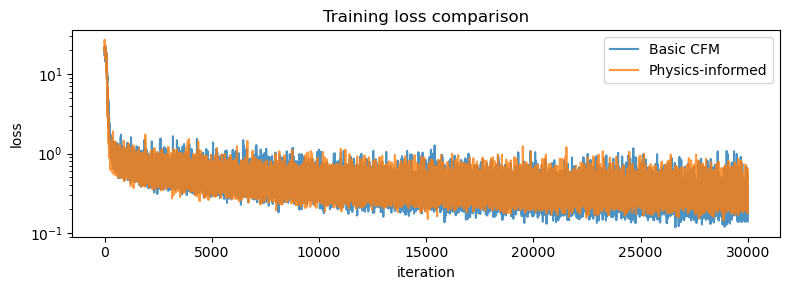

In [11]:
plt.figure(figsize=(8, 3))
plt.semilogy(losses_A, alpha=0.8, label='Basic CFM')
plt.semilogy(losses_B, alpha=0.8, label='Physics-informed')
plt.xlabel('iteration'); plt.ylabel('loss'); plt.legend()
plt.title('Training loss comparison'); plt.tight_layout(); plt.show()

## Evaluation — trajectories

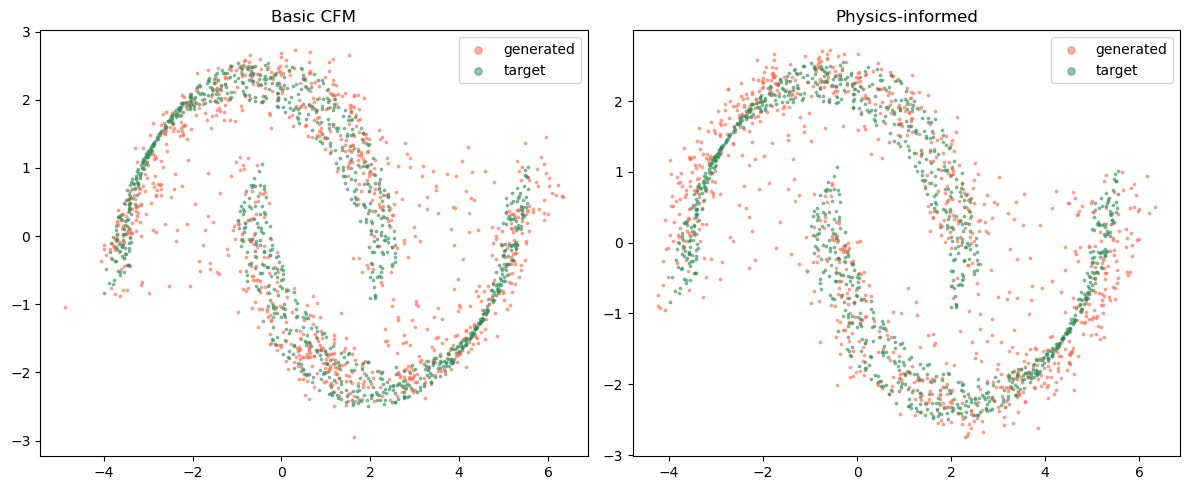

In [12]:
def evaluate_model(model, n_samples=1000):
    model.eval()
    node = NeuralODE(torch_wrapper(model), sensitivity='adjoint', solver='euler')
    with torch.no_grad():
        traj = node.trajectory(
            sample_8gaussians(n_samples).to(device),
            t_span=torch.linspace(0, 1, 100, device=device),
        )
    return traj.cpu()

traj_A = evaluate_model(model_A)
traj_B = evaluate_model(model_B)
x1_ref = sample_moons(1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, traj, title in zip(axes, [traj_A, traj_B], ['Basic CFM', 'Physics-informed']):
    ax.scatter(traj[-1, :, 0], traj[-1, :, 1], s=3, alpha=0.5, c='tomato', label='generated')
    ax.scatter(x1_ref[:, 0], x1_ref[:, 1], s=3, alpha=0.5, c='seagreen', label='target')
    ax.set_title(title); ax.legend(markerscale=3)
plt.tight_layout(); plt.show()

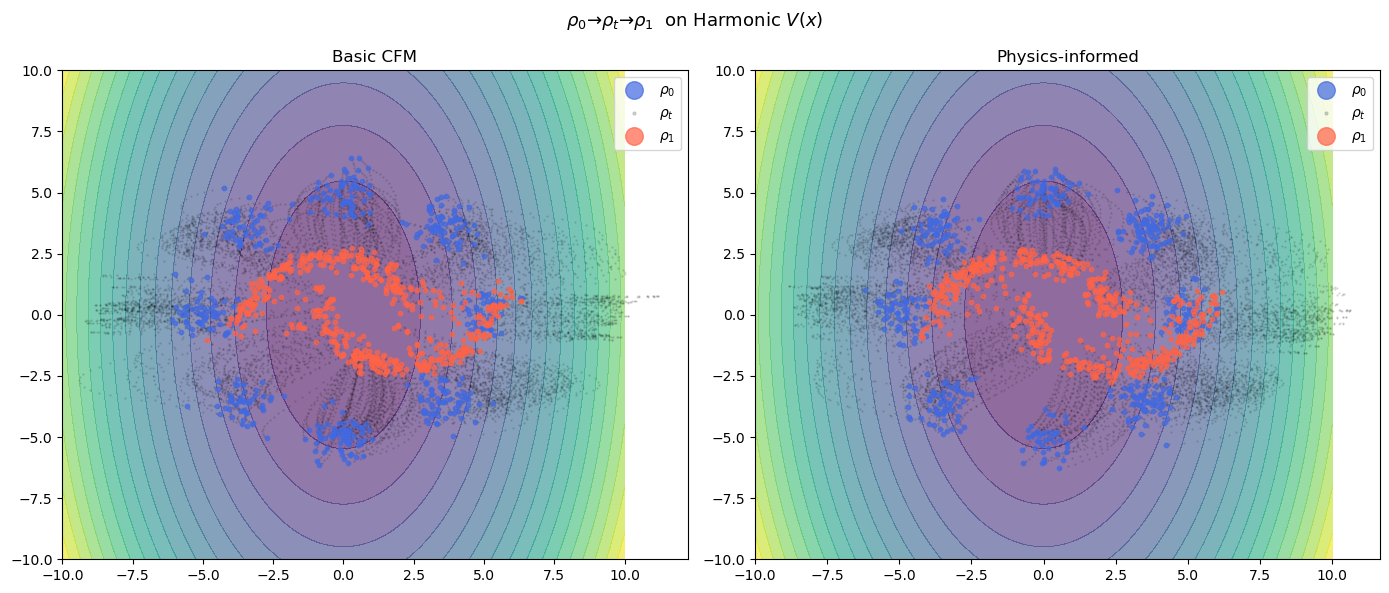

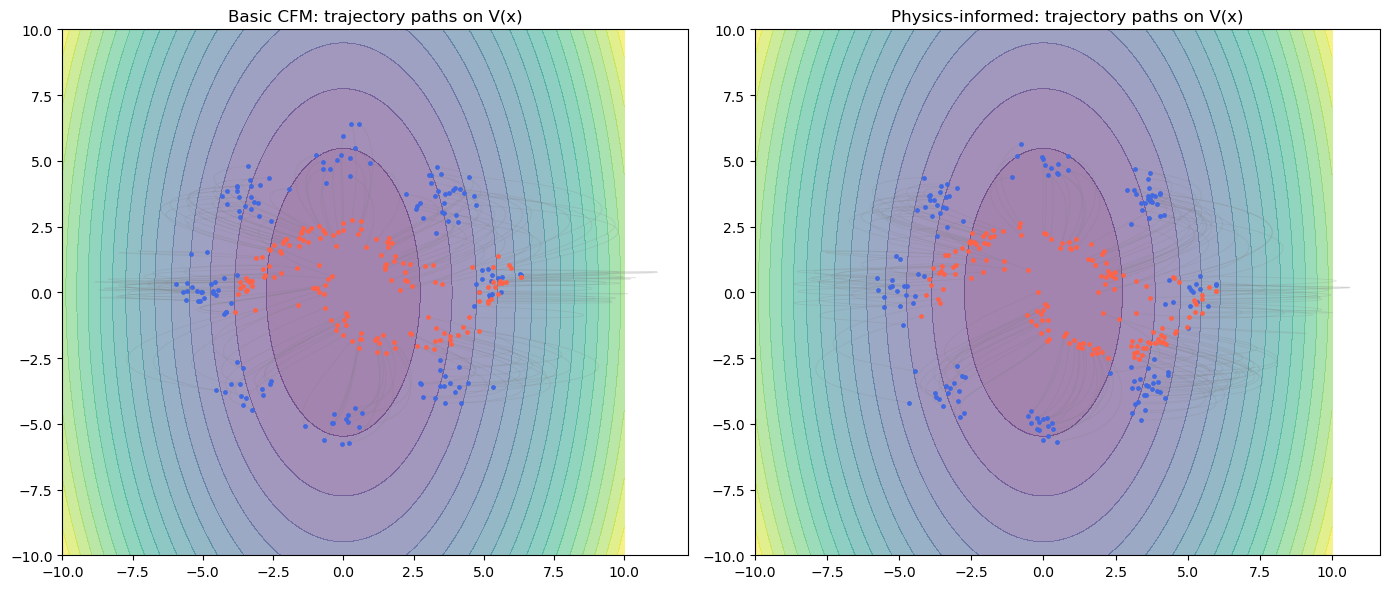

In [13]:
# Trajectories overlaid on potential energy landscape (both variants)
n_show = 500
n_lines = 150

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, traj, label in zip(axes, [traj_A, traj_B], ['Basic CFM', 'Physics-informed']):
    ax.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
    ax.scatter(traj[0, :n_show, 0], traj[0, :n_show, 1],
               s=10, alpha=0.7, c='royalblue', label=r'$\rho_0$', zorder=3)
    ax.scatter(traj[1:-1:5, :n_show, 0].reshape(-1), traj[1:-1:5, :n_show, 1].reshape(-1),
               s=0.3, alpha=0.15, c='black', label=r'$\rho_t$')
    ax.scatter(traj[-1, :n_show, 0], traj[-1, :n_show, 1],
               s=10, alpha=0.7, c='tomato', label=r'$\rho_1$', zorder=3)
    ax.legend(markerscale=4); ax.set_title(label)
plt.suptitle(r'$\rho_0 \to \rho_t \to \rho_1$  on Harmonic $V(x)$', fontsize=13)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, traj, label in zip(axes, [traj_A, traj_B], ['Basic CFM', 'Physics-informed']):
    ax.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.5)
    for i in range(n_lines):
        ax.plot(traj[:, i, 0], traj[:, i, 1], 'gray', alpha=0.2, linewidth=0.6)
    ax.scatter(traj[0, :n_lines, 0], traj[0, :n_lines, 1], s=6, c='royalblue', zorder=3)
    ax.scatter(traj[-1, :n_lines, 0], traj[-1, :n_lines, 1], s=6, c='tomato', zorder=3)
    ax.set_title(f'{label}: trajectory paths on V(x)')
plt.tight_layout(); plt.show()

## Hamiltonian conservation analysis

Measures `(H(t) - H(0)) / H(0)` along generated trajectories.
A well-trained Hamiltonian flow should keep this close to zero.

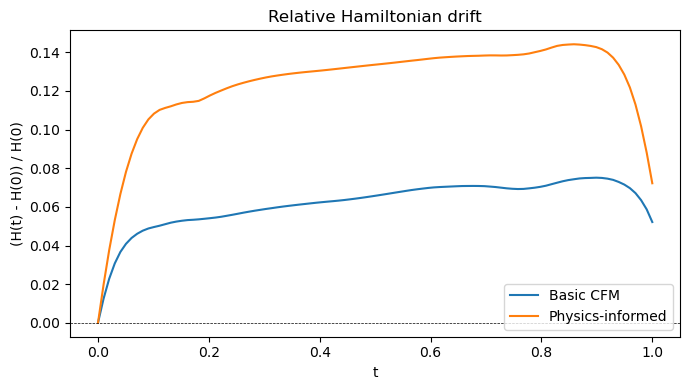

Max |drift| A: 0.0751
Max |drift| B: 0.1442


In [14]:
t_span = torch.linspace(0, 1, 100, device=device)
x0_eval = sample_8gaussians(500).to(device)

node = NeuralODE(torch_wrapper(model_A), sensitivity='adjoint', solver='euler')
with torch.no_grad():
    traj_eval = node.trajectory(x0_eval, t_span=t_span)

H_A = hamiltonian_energy(model_A, potential, traj_eval, t_span)
drift_A = relative_hamiltonian_drift(H_A)

node_B = NeuralODE(torch_wrapper(model_B), sensitivity='adjoint', solver='euler')
with torch.no_grad():
    traj_eval_B = node_B.trajectory(x0_eval, t_span=t_span)

H_B = hamiltonian_energy(model_B, potential, traj_eval_B, t_span)
drift_B = relative_hamiltonian_drift(H_B)

t_np = t_span.cpu().numpy()
plt.figure(figsize=(7, 4))
plt.plot(t_np, drift_A, label='Basic CFM')
plt.plot(t_np, drift_B, label='Physics-informed')
plt.axhline(0, color='k', linewidth=0.5, linestyle='--')
plt.xlabel('t'); plt.ylabel('(H(t) - H(0)) / H(0)')
plt.title('Relative Hamiltonian drift'); plt.legend()
plt.tight_layout(); plt.show()

print(f'Max |drift| A: {np.abs(drift_A).max():.4f}')
print(f'Max |drift| B: {np.abs(drift_B).max():.4f}')